<div align="center">

# Data Projects and Hackathon 3  
## Project 
Sergio Fernandez, Alessandro Mecchia 

</div>

.

In [3]:
import pandas as pd
import json
import json
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import numpy as np
from transformers import pipeline
import requests
import time
from pathlib import Path
import subprocess
import sys
import time
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from pathlib import Path

try:
    import pyarrow as pa
    import pyarrow.json as paj
    import pyarrow.parquet as pq
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow"])
    import pyarrow as pa
    import pyarrow.json as paj
    import pyarrow.parquet as pq
    
import pyarrow.parquet as pq

import pyarrow.parquet as pq
import ipywidgets as widgets
from IPython.display import display

In [4]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

## Functions 

In [5]:
def pct(x): 
    return f"{x:,} ({x/n*100:.1f}%)"

def is_empty(val):
    if val is None:
        return True
    if isinstance(val, str):
        return val == ""
    if isinstance(val, (list, np.ndarray)):
        return len(val) == 0
    return False

In [6]:
import json

def impute_with_cache(df, col, fetch_fn, cache_path):
    cache_path = Path(cache_path)
    mask = df[col].apply(is_empty) & ~df["doi"].apply(is_empty)
    missing_df = df[mask]

    if cache_path.exists():
        with open(cache_path, "r") as f:
            recovered = {int(k): v for k, v in json.load(f).items()}
        print(f"Cache found: loaded {len(recovered)} values from {cache_path}")
    else:
        recovered = {}
        for i, (idx, row) in enumerate(missing_df.iterrows()):
            value = fetch_fn(row["doi"])
            if value:
                recovered[idx] = value

            if (i + 1) % 10 == 0:
                print(f"  [{i+1}/{len(missing_df)}] recovered until now: {len(recovered)}")

            time.sleep(0.1)

        with open(cache_path, "w") as f:
            json.dump(recovered, f)
        print(f"Cache saved to {cache_path}")

    for idx, value in recovered.items():
        df.at[idx, col] = value

    print(f"\nImputation completed:")
    print(f"'{col}' records with DOI available: {mask.sum()}")
    print(f"'{col}' values successfully recovered: {len(recovered)} ({len(recovered)/mask.sum()*100:.1f}%)")
    missing_total = df[col].apply(is_empty).sum()
    print(f"'{col}' still missing (total): {missing_total}")

In [7]:
def get_lang_from_openalex(doi):
    if not doi or doi == "":
        return None
    try:
        r = requests.get(
            f"https://api.openalex.org/works/https://doi.org/{doi}",
            headers={"User-Agent": "DBLP-imputation/1.0"},
            timeout=10
        )
        if r.status_code != 200:
            return None
        return r.json().get("language", None)
    except Exception:
        return None


def get_keywords_from_openalex(doi):
    if not doi or doi == "":
        return None
    try:
        r = requests.get(
            f"https://api.openalex.org/works/https://doi.org/{doi}",
            headers={"User-Agent": "DBLP-imputation/1.0"},
            timeout=10
        )
        if r.status_code != 200:
            return None
        concepts = r.json().get("concepts", [])
        keywords = [
            c["display_name"] for c in concepts
            if c.get("level", 0) >= 1 and c.get("score", 0) >= 0.3
        ]
        return keywords if keywords else None
    except Exception:
        return None
    
def get_abstract_from_openalex(doi):
    if not doi or doi == "":
        return None
    try:
        r = requests.get(
            f"https://api.openalex.org/works/https://doi.org/{doi}",
            headers={"User-Agent": "DBLP-imputation/1.0"},
            timeout=10
        )
        if r.status_code != 200:
            return None
        
        data = r.json()
        inverted_index = data.get("abstract_inverted_index")
        
        if not inverted_index:
            return None
        
        max_pos = max([max(positions) for positions in inverted_index.values() if positions], default=0)
        
        if max_pos == 0:
            return None
        
        words = [''] * (max_pos + 1)
        for word, positions in inverted_index.items():
            for pos in positions:
                words[pos] = word
        
        return ' '.join(words).strip()
    except Exception:
        return None
    

def get_venue_from_openalex(doi):
    if not doi or doi == "":
        return None
    try:
        r = requests.get(
            f"https://api.openalex.org/works/https://doi.org/{doi}",
            headers={"User-Agent": "DBLP-imputation/1.0"},
            timeout=10
        )
        if r.status_code != 200:
            return None
        
        data = r.json()
        venue = data.get("primary_location", {}).get("raw_source_name")
        return venue if venue else None
    except Exception:
        return None
    
def get_doc_type_from_openalex(doi):
    if not doi or doi == "":
        return None
    try:
        r = requests.get(
            f"https://api.openalex.org/works/https://doi.org/{doi}",
            headers={"User-Agent": "DBLP-imputation/1.0"},
            timeout=10
        )
        if r.status_code != 200:
            return None
        
        data = r.json()
        doc_type = data.get("type")
        return doc_type if doc_type else None
    except Exception:
        return None
    
def get_references_from_openalex(doi):
    if not doi or doi == "":
        return None
    try:
        r = requests.get(
            f"https://api.openalex.org/works/https://doi.org/{doi}",
            headers={"User-Agent": "DBLP-imputation/1.0"},
            timeout=10
        )
        if r.status_code != 200:
            return None
        
        data = r.json()
        references = data.get("referenced_works", [])
        return references if references else None
    except Exception:
        return None


## Data Creation 

da eseguire una sola volta 

In [8]:
DATA_DIR = Path("data")
SOURCE_PATH = DATA_DIR / "DBLP-Citation-network-V18.jsonl"
TARGET_PATH = DATA_DIR / "DBLP-Citation-network-V18.parquet"
BLOCK_SIZE = 64 * 1024 * 1024  

if not SOURCE_PATH.exists():
    raise FileNotFoundError(f"File non trovato: {SOURCE_PATH}")

if pa.Codec.is_available("zstd"):
    COMPRESSION = "zstd"
elif pa.Codec.is_available("snappy"):
    COMPRESSION = "snappy"
else:
    COMPRESSION = None

print(f"Input : {SOURCE_PATH} ({SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB)")
print(f"Output: {TARGET_PATH}")
print(f"Compressione: {COMPRESSION}")
print(f"Block size: {BLOCK_SIZE / 1024**2:.0f} MiB")

Input : data\DBLP-Citation-network-V18.jsonl (14.85 GiB)
Output: data\DBLP-Citation-network-V18.parquet
Compressione: zstd
Block size: 64 MiB


In [9]:
if TARGET_PATH.exists():
    print(f"Parquet already exists, skipping conversion.")
else:
    reader = paj.open_json(
        SOURCE_PATH,
        read_options=paj.ReadOptions(block_size=BLOCK_SIZE),
    )

    writer = None
    rows_written = 0
    batches_written = 0
    started_at = time.perf_counter()

    try:
        while True:
            try:
                batch = reader.read_next_batch()
            except StopIteration:
                break

            if writer is None:
                writer = pq.ParquetWriter(
                    TARGET_PATH,
                    batch.schema,
                    compression=COMPRESSION,
                )

            writer.write_batch(batch)
            rows_written += batch.num_rows
            batches_written += 1

            if batches_written % 25 == 0:
                elapsed = time.perf_counter() - started_at
                print(f"Batch: {batches_written:>5} | Rows: {rows_written:>12,} | Elapsed: {elapsed:>8.1f}s")

        if writer is None:
            raise RuntimeError("JSONL file seems empty: no batch read.")
    finally:
        reader.close()
        if writer is not None:
            writer.close()

    elapsed = time.perf_counter() - started_at
    print(f"Conversion completed in {elapsed:.1f}s")
    print(f"Rows written : {rows_written:,}")
    print(f"JSONL size   : {SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB")
    print(f"Parquet size : {TARGET_PATH.stat().st_size / 1024**3:.2f} GiB")

Parquet already exists, skipping conversion.


## Data Exploration 

In [10]:
pf = pq.ParquetFile(r"data/DBLP-Citation-network-V18.parquet")

print(f"Total rows   : {pf.metadata.num_rows:,}")
print(f"Columns      : {pf.metadata.num_columns}")
print(f"Row groups   : {pf.metadata.num_row_groups}")

Total rows   : 6,729,828
Columns      : 21
Row groups   : 238


In [11]:
for i, name in enumerate(pf.schema_arrow.names):
    print(f"{i}. {name}")

0. id
1. title
2. abstract
3. keywords
4. year
5. authors
6. references
7. page_start
8. page_end
9. lang
10. volume
11. issue
12. issn
13. isbn
14. doi
15. url
16. n_citation
17. venue
18. doc_type


In [12]:
pf = pq.ParquetFile(r"data/DBLP-Citation-network-V18.parquet")
columns = pf.schema_arrow.names

dropdown = widgets.Dropdown(options=columns, description="Colonna:")
output = widgets.Output()

def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        with output:
            output.clear_output()
            batch = next(pf.iter_batches(batch_size=10, columns=[change["new"]]))
            df = batch.to_pandas()
            display(df[change["new"]])

dropdown.observe(on_change)
display(dropdown, output)

Dropdown(description='Colonna:', options=('id', 'title', 'abstract', 'keywords', 'year', 'authors', 'reference…

Output()

In [13]:
batch = next(pf.iter_batches(batch_size=1))
paper = batch.to_pandas().iloc[0]

for col, val in paper.items():
    print(f"{col:15}: {val}")

id             : 5390877920f70186a0d2ce7f
title          : Top-Down Construction of 3-D Mechanical Object Shapes from Engineering Drawings
abstract       : 
keywords       : ['First Page' '3-D Mechanical Object Shapes' 'Engineering Drawings'
 'Top-Down Construction']
year           : 1984
authors        : [{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H YOSHIURA', 'org': 'Hitachi Research Laboratory, Hitachi Ltd.'}
 {'id': '5608ec4a45cedb3396db2920', 'name': 'K FUJIMURA', 'org': 'Univ. of Tokyo, Tokyo, Japan'}
 {'id': '548a62d3dabfae8a11fb49e2', 'name': 'TL KUNII', 'org': None}]
references     : ['5390962020f70186a0df3bf2' '5390879d20f70186a0d43d74'
 '5390a1e620f70186a0e59c05' '5390b1d220f70186a0ee1bd6'
 '53909f8220f70186a0e3cfc7' '5390962020f70186a0df3f87'
 '53e9b8a8b7602d970447e86b']
page_start     : 32
page_end       : 40
lang           : en
volume         : 17
issue          : 12
issn           : 0018-9162
isbn           : 
doi            : 10.1109/mc.1984.1659026
url            : []

### Missing values 

In [14]:
batch = next(pf.iter_batches(batch_size=10_000))
df = batch.to_pandas()
n = len(df)

# SALVA I COUNT INIZIALI
missing_count_before = {}

# Simple columns
for col in ["id", "title", "abstract", "year", "page_start", "page_end",
            "lang", "volume", "issue", "issn", "isbn", "doi", "venue", "doc_type"]:
    missing = df[col].apply(is_empty).sum()
    missing_count_before[col] = missing
    print(f"  {col:15}: {pct(missing)}")

# Lists
print()
for col in ["keywords", "references", "url"]:
    missing = df[col].apply(is_empty).sum()
    missing_count_before[col] = missing
    print(f"  {col:15}: {pct(missing)}")

# Authors 
print()
authors_flat = pd.DataFrame(df["authors"].explode().dropna().tolist())
total_authors = len(authors_flat)

missing_authors_before = {}
for col in ["id", "name", "org"]:
    missing = authors_flat[col].apply(is_empty).sum()
    if col != "name":  # Non salvare "name" perché ha 0% mancanti
        missing_authors_before[f"authors.{col}"] = missing
    print(f"  authors.{col:10}: {missing:,} ({missing/total_authors*100:.1f}% of autors)")

  id             : 0 (0.0%)
  title          : 0 (0.0%)
  abstract       : 516 (5.2%)
  year           : 0 (0.0%)
  page_start     : 2,318 (23.2%)
  page_end       : 2,460 (24.6%)
  lang           : 292 (2.9%)
  volume         : 4,764 (47.6%)
  issue          : 6,610 (66.1%)
  issn           : 4,710 (47.1%)
  isbn           : 9,847 (98.5%)
  doi            : 875 (8.8%)
  venue          : 56 (0.6%)
  doc_type       : 15 (0.1%)

  keywords       : 1,516 (15.2%)
  references     : 1,668 (16.7%)
  url            : 946 (9.5%)

  authors.id        : 2,789 (8.6% of autors)
  authors.name      : 0 (0.0% of autors)
  authors.org       : 5,990 (18.5% of autors)


spiegare che ci interessa imputare solo le variabili che pensiamo possano essere utili per predirre il numero di citazioni o se un paper cita un'altro, ma prima potrebbe essere utile analizzare la distribuzione nei anni dei missing value.

In [15]:
print(f"Min year: {df['year'].min()}")
print(f"Max year: {df['year'].max()}")

Min year: 210
Max year: 2026


In [16]:
papers = df.sort_values("year").reset_index(drop=True)
current = [0]

def show_paper(idx):
    paper = papers.iloc[idx]
    print(f"Paper {idx+1} / {len(papers)}")
    print(f"{'─'*60}")
    for col, val in paper.items():
        print(f"  {col:15}: {val}")

prev_btn = widgets.Button(description="Prev")
next_btn = widgets.Button(description="Next")
out = widgets.Output()

def on_prev(_):
    if current[0] > 0:
        current[0] -= 1
    with out:
        out.clear_output()
        show_paper(current[0])

def on_next(_):
    if current[0] < len(papers) - 1:
        current[0] += 1
    with out:
        out.clear_output()
        show_paper(current[0])

prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

with out:
    show_paper(current[0])

display(widgets.HBox([prev_btn, next_btn]), out)

Output()

come possiamo notare i primi due paper hanno delle date strane, per sicurezza abbiamo deciso di compararli usando il url e vedere se combaciano, dopo aver controllato i primi 15 abbiamo visto che i primi due avevano la data sbagliata

In [17]:
sorted_idx = df["year"].sort_values().index

df.loc[sorted_idx[0], "year"] = 2006
df.loc[sorted_idx[1], "year"] = 1976

print(f"Min year: {df['year'].min()}")
print(f"Max year: {df['year'].max()}")

Min year: 1956
Max year: 2026


C:\Users\ms\AppData\Local\Temp\ipykernel_19512\2897838566.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sum(g[col].apply(is_empty).sum() for col in ["abstract", "keywords", "lang", "venue", "doi", "references"]))


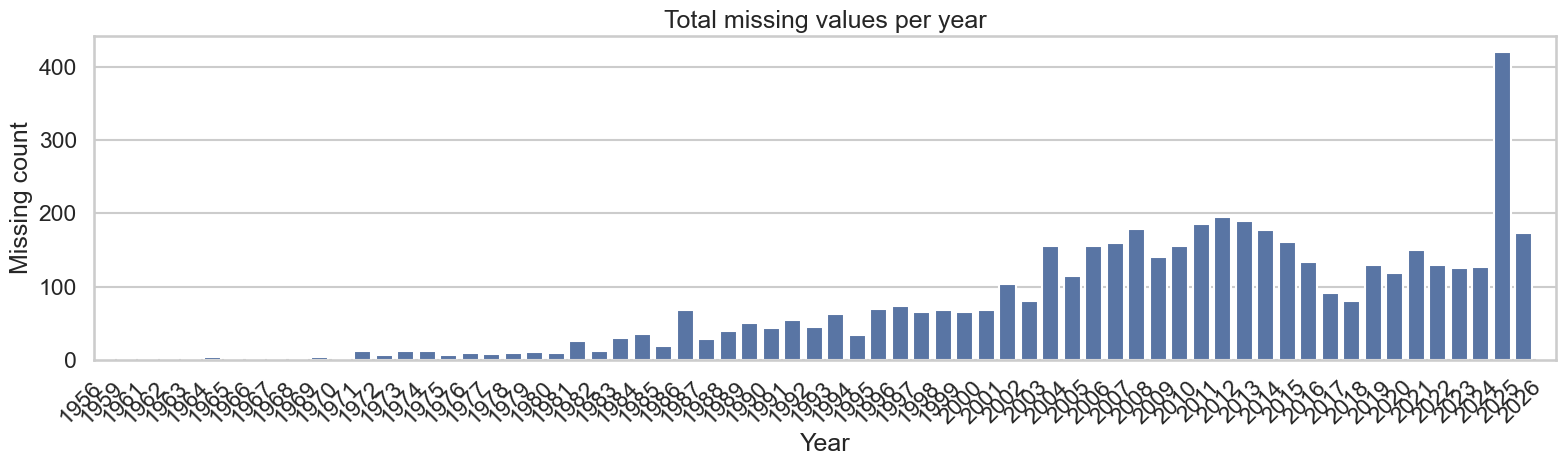

In [18]:
missing_by_year = (
    df.dropna(subset=["year"])
    .assign(year=lambda x: x["year"].astype(int))
    .groupby("year")
    .apply(lambda g: sum(g[col].apply(is_empty).sum() for col in ["abstract", "keywords", "lang", "venue", "doi", "references"]))
    .reset_index(name="missing_count")
)

plt.figure(figsize=(16, 5))
sns.barplot(data=missing_by_year, x="year", y="missing_count", color="#4C72B0")
plt.title("Total missing values per year")
plt.xlabel("Year")
plt.ylabel("Missing count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 1. Abstract imputation

In [19]:
impute_with_cache(df, "abstract", get_abstract_from_openalex, "data/cache_abstract.json")

Cache found: loaded 63 values from data\cache_abstract.json

Imputation completed:
'abstract' records with DOI available: 234
'abstract' values successfully recovered: 63 (26.9%)
'abstract' still missing (total): 453


#### 2. Lang imputation

spiegare che se avessivo avuto accesso ha una parte del paper avremmo potuto usare un modello dei trasformer per analizzare la scrittura del paper e imputare in modo corretto la lingua del paper, siccome non è il caso possiamo provare altri metodi. 

Prima di tutto dobbiamo vedere le possibilità o comunque i valori che abbiamo presenti, in caso fossero tutti inglesi allora li mettiamo inglesi tutti. 

In [20]:
lang_counts = df["lang"].value_counts(dropna=False)
lang_counts.index = lang_counts.index.fillna("(null)")
print(f"Unique values of 'lang' (sample of {n:,} rows):\n")
print(lang_counts.to_string())

Unique values of 'lang' (sample of 10,000 rows):

lang
en    9653
       292
de      41
fr       9
pt       2
zh       2
da       1


spiegare che come vediamo abbiamo diverse lingue nel dataset, quindi decidiamo di usare un modello (spiegare il modello)

In [21]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

SUPPORTED_LANGS = {"en", "de", "fr", "pt", "es", "it", "zh", "ja", "ko", "ru"}

def detect_lang(row):
    parts = []
    for col in ["title", "abstract", "venue"]:
        val = row.get(col)
        if isinstance(val, str) and val.strip():
            parts.append(val.strip())
    
    text = " ".join(parts)
    
    if len(text) < 30:
        return None
    
    try:
        pred = detect(text)
        return pred if pred in SUPPORTED_LANGS else None
    except:
        return None

missing_lang_mask = df["lang"].apply(is_empty)

df.loc[missing_lang_mask, "lang"] = (
    df.loc[missing_lang_mask]
      .apply(detect_lang, axis=1)
)

In [22]:
lang_counts = df["lang"].value_counts(dropna=False)
lang_counts.index = [
    "(null)" if pd.isna(x) or x == "" else x
    for x in lang_counts.index
]

print(f"Unique values of 'lang' (sample of {n:,} rows):\n")
print(lang_counts.to_string())


Unique values of 'lang' (sample of 10,000 rows):

en    9930
de      52
fr      11
pt       4
zh       2
da       1


come possiamo vedere non abbiamo più valori nan 

#### 3. Keywords imputation

come primo tentativo possiamo vedere se con il doi e usando onealex possiamo ottenere delle keywords 

In [23]:
impute_with_cache(df, "keywords", get_keywords_from_openalex, "data/cache_keywords.json")

Cache found: loaded 951 values from data\cache_keywords.json

Imputation completed:
'keywords' records with DOI available: 1011
'keywords' values successfully recovered: 951 (94.1%)
'keywords' still missing (total): 565


siamo riusciti ad imputare un totale di circa 951 valori, i rimanenti sono dovuti a richieste mancanti di DOI, per il resto possiamo generarli partendo dall'absatract

In [ ]:
CACHE_PATH = Path("data/cache_keywords_transformer.json")

tokenizer = AutoTokenizer.from_pretrained("fabiochiu/t5-base-tag-generation")
model = AutoModelForSeq2SeqLM.from_pretrained("fabiochiu/t5-base-tag-generation")

def extract_keywords_from_abstract(abstract):
    if not abstract or abstract == "":
        return None
    try:
        inputs = tokenizer.encode(abstract[:512], return_tensors="pt", max_length=512, truncation=True)
        outputs = model.generate(inputs, max_length=50, num_beams=4, early_stopping=True)
        result = tokenizer.decode(outputs[0], skip_special_tokens=True)
        keywords = [kw.strip() for kw in result.split(",") if kw.strip()]
        return keywords if keywords else None
    except Exception as e:
        print(f"Error processing abstract: {e}")
        return None

mask = df["keywords"].apply(is_empty) & ~df["abstract"].apply(is_empty)
print(f"Records to impute with transformer: {mask.sum()}")

# Load cache if exists
if CACHE_PATH.exists():
    with open(CACHE_PATH, "r") as f:
        recovered = {int(k): v for k, v in json.load(f).items()}
    print(f"Cache found: loaded {len(recovered)} values")
    for idx, keywords in recovered.items():
        df.at[idx, "keywords"] = keywords
else:
    recovered = {}
    for i, (idx, row) in enumerate(df[mask].iterrows()):
        keywords = extract_keywords_from_abstract(row["abstract"])
        if keywords:
            df.at[idx, "keywords"] = keywords
            recovered[idx] = keywords
        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{mask.sum()}] recovered so far: {len(recovered)}")

    with open(CACHE_PATH, "w") as f:
        json.dump(recovered, f)
    print(f"Cache saved to {CACHE_PATH}")

print(f"Still missing: {df['keywords'].apply(is_empty).sum()}")

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Records to impute with transformer: 334
  [10/334] recovered so far: 10
  [20/334] recovered so far: 20
  [30/334] recovered so far: 30
  [40/334] recovered so far: 40
  [50/334] recovered so far: 50
  [60/334] recovered so far: 60
  [70/334] recovered so far: 70
  [80/334] recovered so far: 80
  [90/334] recovered so far: 90
  [100/334] recovered so far: 100
  [110/334] recovered so far: 110
  [120/334] recovered so far: 120
  [130/334] recovered so far: 130
  [140/334] recovered so far: 140
  [150/334] recovered so far: 150
  [160/334] recovered so far: 160
  [170/334] recovered so far: 170
  [180/334] recovered so far: 180
  [190/334] recovered so far: 190
  [200/334] recovered so far: 200
  [210/334] recovered so far: 210
  [220/334] recovered so far: 220
  [230/334] recovered so far: 230
  [240/334] recovered so far: 240
  [250/334] recovered so far: 250
  [260/334] recovered so far: 260
  [270/334] recovered so far: 270
  [280/334] recovered so far: 280
  [290/334] recovered so f

come possiamo notare i rimanenti sono dovuti alla mancanza di un abstract il quale non ci permette di fare l'imputazione 

#### 4. Venue

In [25]:
impute_with_cache(df, "venue", get_venue_from_openalex, "data/cache_venue.json")

Cache found: loaded 42 values from data\cache_venue.json

Imputation completed:
'venue' records with DOI available: 46
'venue' values successfully recovered: 42 (91.3%)
'venue' still missing (total): 14


#### 5. Doc_type

In [26]:
impute_with_cache(df, "doc_type", get_doc_type_from_openalex, "data/cache_doc_type.json")

Cache found: loaded 5 values from data\cache_doc_type.json

Imputation completed:
'doc_type' records with DOI available: 5
'doc_type' values successfully recovered: 5 (100.0%)
'doc_type' still missing (total): 10


#### 6. Reverence

In [27]:
impute_with_cache(df, "references", get_references_from_openalex, "data/cache_references.json")

Cache found: loaded 858 values from data\cache_references.json

Imputation completed:
'references' records with DOI available: 1299
'references' values successfully recovered: 858 (66.1%)
'references' still missing (total): 810


#### 7. Authors.id

In [28]:
def impute_authors_id(df):
    """
    Imputa authors.id cercando lo stesso nome in altri paper
    Se trova lo stesso nome, usa l'id già assegnato
    """
    
    # Crea un mapping: nome -> id (da paper dove abbiamo l'id)
    name_to_id = {}
    
    for idx, row in df.iterrows():
        authors = row.get("authors")
        if authors is not None and len(authors) > 0:  # Cambia qui
            for author in authors:
                if isinstance(author, dict):
                    name = author.get("name")
                    author_id = author.get("id")
                    # Se abbiamo sia nome che id, salvalo nel mapping
                    if name and author_id:
                        if name not in name_to_id:
                            name_to_id[name] = author_id
    
    print(f"Created mapping for {len(name_to_id):,} unique author names")
    
    # Ora imputa gli id mancanti usando il mapping
    recovered = 0
    for idx, row in df.iterrows():
        authors = row.get("authors")
        if authors is not None and len(authors) > 0:  # Cambia qui
            for author in authors:
                if isinstance(author, dict):
                    name = author.get("name")
                    author_id = author.get("id")
                    # Se manca l'id ma abbiamo il nome, usa il mapping
                    if not author_id and name and name in name_to_id:
                        author["id"] = name_to_id[name]
                        recovered += 1
    
    print(f"Recovered {recovered:,} author IDs")
    return df

In [29]:
df = impute_authors_id(df)

Created mapping for 28,123 unique author names
Recovered 162 author IDs


#### 8. Authors.org

In [30]:
def impute_authors_org(df):
    """
    Imputa authors.org usando il paper più vicino temporalmente (±365 giorni)
    dello stesso autore
    """
    
    # Mapping: (author_name, year) -> org (da paper dove abbiamo org)
    author_year_to_org = {}
    
    # Prima pass: costruisci il mapping
    for idx, row in df.iterrows():
        year = row.get("year")
        authors = row.get("authors")
        
        if year is not None and authors is not None and len(authors) > 0:  # Cambia qui
            for author in authors:
                if isinstance(author, dict):
                    name = author.get("name")
                    org = author.get("org")
                    # Se abbiamo nome, anno e org, salvalo
                    if name and org:
                        try:
                            key = (name, int(year))
                            if key not in author_year_to_org:
                                author_year_to_org[key] = org
                        except:
                            pass
    
    print(f"Created mapping for {len(author_year_to_org):,} (author, year) pairs")
    
    # Seconda pass: imputa gli org mancanti
    recovered = 0
    for idx, row in df.iterrows():
        year = row.get("year")
        authors = row.get("authors")
        
        if year is not None and authors is not None and len(authors) > 0:  # Cambia qui
            try:
                year = int(year)
                for author in authors:
                    if isinstance(author, dict):
                        name = author.get("name")
                        org = author.get("org")
                        
                        # Se manca org ma abbiamo nome e anno
                        if not org and name:
                            # Cerca nel range ±365 giorni
                            best_org = None
                            best_distance = float('inf')
                            
                            for (author_name, author_year), author_org in author_year_to_org.items():
                                if author_name == name:
                                    distance = abs(author_year - year)
                                    if distance <= 365 and distance < best_distance:
                                        best_org = author_org
                                        best_distance = distance
                            
                            if best_org:
                                author["org"] = best_org
                                recovered += 1
            except:
                pass
    
    print(f"Recovered {recovered:,} author ORGs")
    return df

In [31]:
# Esegui
df = impute_authors_org(df)

Created mapping for 26,299 (author, year) pairs
Recovered 417 author ORGs


#### Comparison missing values 

In [32]:
missing_count_after = {}

# Simple columns
for col in ["id", "title", "abstract", "year", "page_start", "page_end",
            "lang", "volume", "issue", "issn", "isbn", "doi", "venue", "doc_type"]:
    missing_count_after[col] = df[col].apply(is_empty).sum()

# Lists
for col in ["keywords", "references", "url"]:
    missing_count_after[col] = df[col].apply(is_empty).sum()

# Authors AFTER
authors_flat_after = pd.DataFrame(df["authors"].explode().dropna().tolist())
missing_authors_after = {}
for col in ["id", "org"]:
    missing = authors_flat_after[col].apply(is_empty).sum()
    missing_authors_after[f"authors.{col}"] = missing

missing_count_after["authors.id"] = missing_authors_after["authors.id"]
missing_count_after["authors.org"] = missing_authors_after["authors.org"]

In [33]:
import plotly.graph_objects as go

imputated_cols = ["abstract", "lang", "keywords", "venue", "doc_type", "references", "authors.id", "authors.org"]  

cols_to_plot = []
before = []
after = []

for col in imputated_cols:
    if col in missing_count_before.keys():
        cols_to_plot.append(col)
        before.append(missing_count_before[col])
        after.append(missing_count_after[col])
    elif col in missing_authors_before.keys():
        cols_to_plot.append(col)
        before.append(missing_authors_before[col])
        after.append(missing_authors_after[col])

improvement = [(b - a) for b, a in zip(before, after)]
improvement_pct = [((b - a) / b * 100) if b > 0 else 0 for b, a in zip(before, after)]

fig = go.Figure(data=[
    go.Bar(name='Before', x=cols_to_plot, y=before, marker_color='#E45756'),
    go.Bar(name='After', x=cols_to_plot, y=after, marker_color='#54A24B'),
    go.Bar(name='Recovered', x=cols_to_plot, y=improvement, marker_color='#4C72B0')
])

fig.update_layout(
    title="Missing Values: Before vs After Imputation (All Imputated Columns)",
    xaxis_title="Column",
    yaxis_title="Missing Count",
    barmode='group',
    height=600,
    template='plotly_white',
    hovermode='x unified',
    font=dict(size=12)
)

fig.show()

## Data Visualizzation 

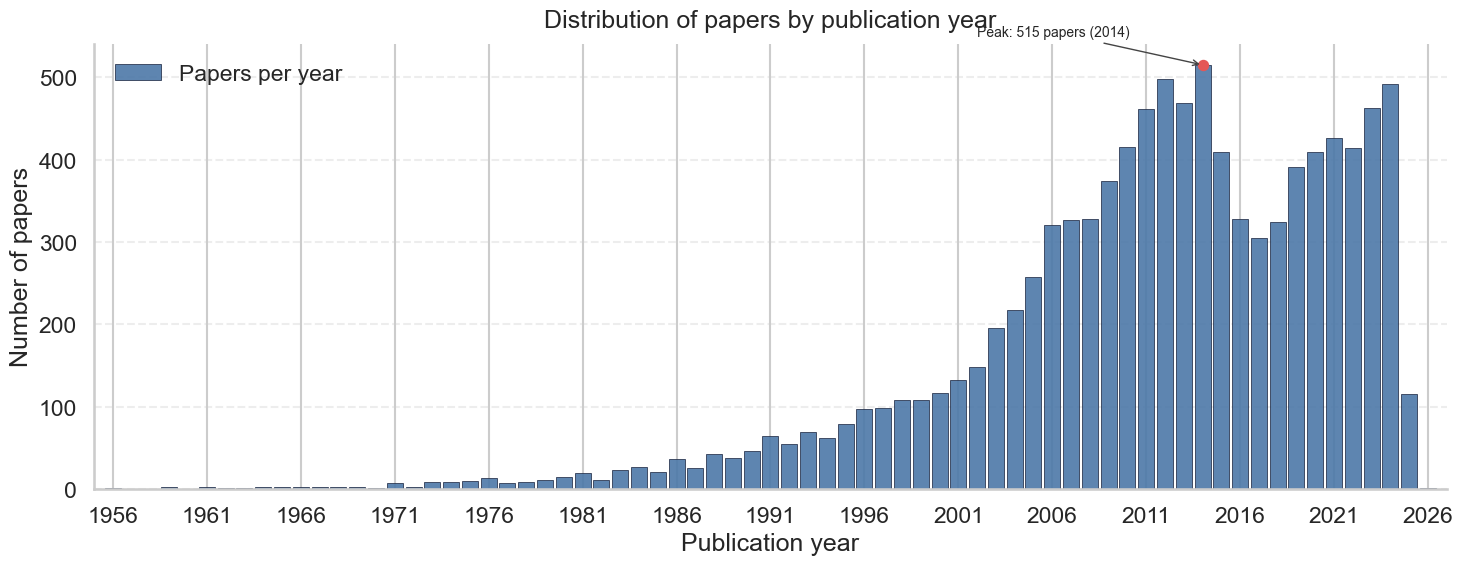

In [34]:
year_counts = (
    df["year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts = year_counts.reindex(
    range(year_counts.index.min(), year_counts.index.max() + 1),
    fill_value=0
)
rolling_avg = year_counts.rolling(window=5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    year_counts.index,
    year_counts.values,
    width=0.85,
    color="#4C78A8",
    edgecolor="#1F2A44",
    linewidth=0.6,
    alpha=0.9,
    label="Papers per year"
)

peak_year = int(year_counts.idxmax())
peak_value = int(year_counts.max())
ax.scatter([peak_year], [peak_value], color="#E45756", s=45, zorder=3)
ax.annotate(
    f"Peak: {peak_value} papers ({peak_year})",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 12, peak_value + 35),
    arrowprops=dict(arrowstyle="->", color="#444444", lw=1),
    fontsize=10
)

tick_years = list(range(year_counts.index.min(), year_counts.index.max() + 1, 5))
if year_counts.index.max() not in tick_years:
    tick_years.append(year_counts.index.max())

ax.set_xticks(tick_years)
ax.set_xlim(year_counts.index.min() - 1, year_counts.index.max() + 1)
ax.set_title("Distribution of papers by publication year", pad=12)
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of papers")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

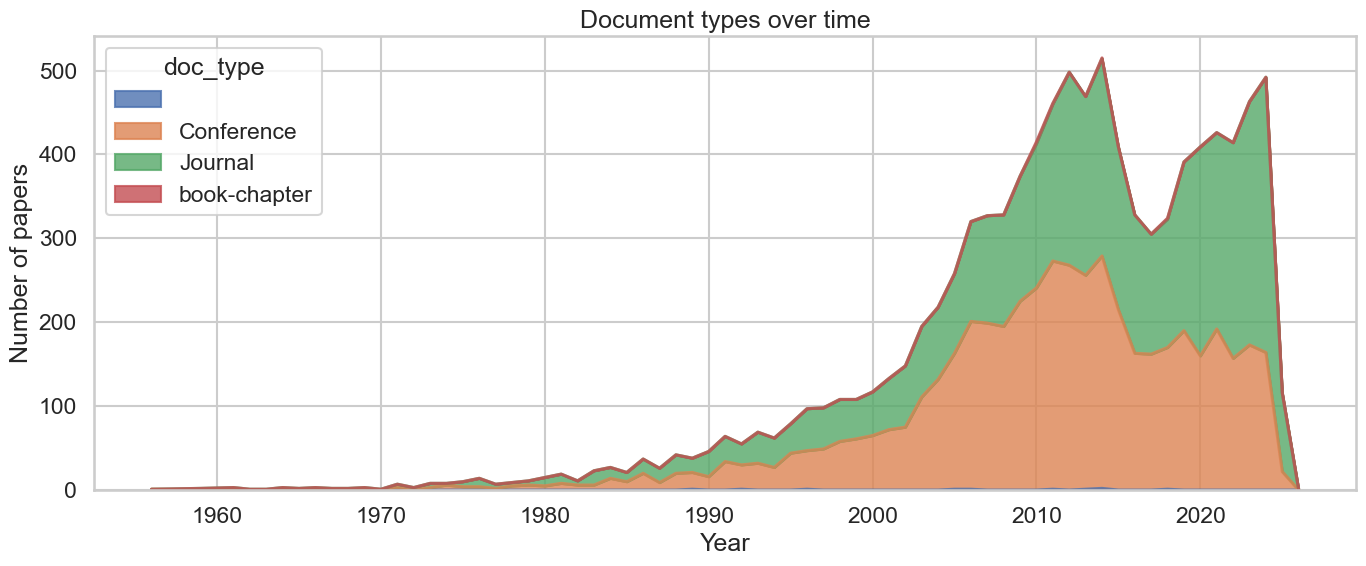

In [35]:
tmp = (
    df.dropna(subset=["year"])
      .assign(year=lambda x: x["year"].astype(int))
      .groupby(["year", "doc_type"])
      .size()
      .unstack(fill_value=0)
)

tmp.plot.area(figsize=(14, 6), alpha=0.8)
plt.title("Document types over time")
plt.xlabel("Year")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()


In [36]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

,missing_count,missing_pct
isbn,9847,98.47
issn,4710,47.10
doi,875,8.75
references,810,8.10
abstract,453,4.53
keywords,231,2.31
venue,14,0.14
doc_type,10,0.10
id,0,0.00
lang,0,0.00


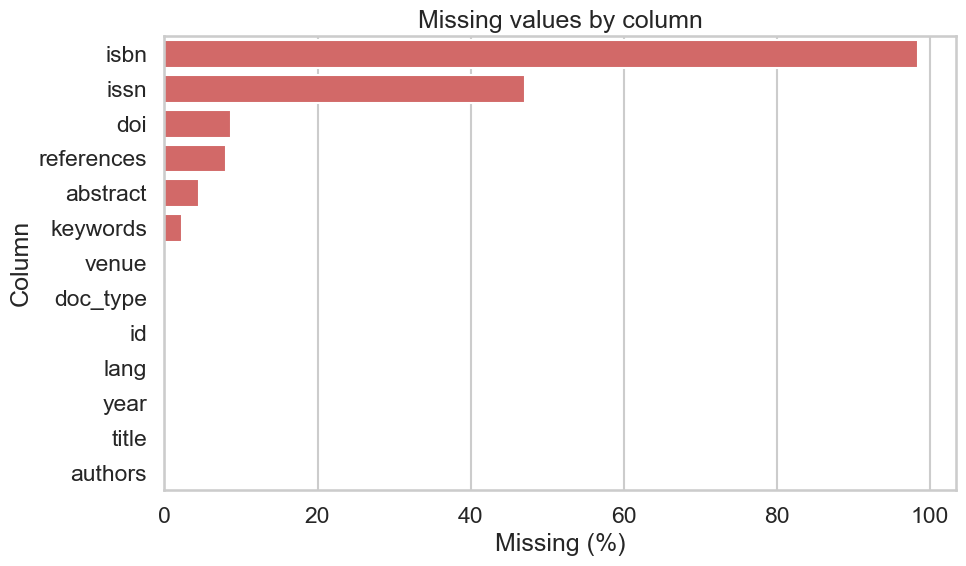

In [37]:
cols_to_check = ["id", "title", "abstract", "year", "lang", "venue", "doc_type",
                 "keywords", "references", "doi", "issn", "isbn", "authors"]

missing_summary = pd.DataFrame({
    "missing_count": [df[col].apply(is_empty).sum() for col in cols_to_check],
    "missing_pct": [df[col].apply(is_empty).mean() * 100 for col in cols_to_check]
}, index=cols_to_check).sort_values("missing_pct", ascending=False)

display(missing_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_summary.reset_index(),
    x="missing_pct",
    y="index",
    color="#E45756"
)
plt.title("Missing values by column")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


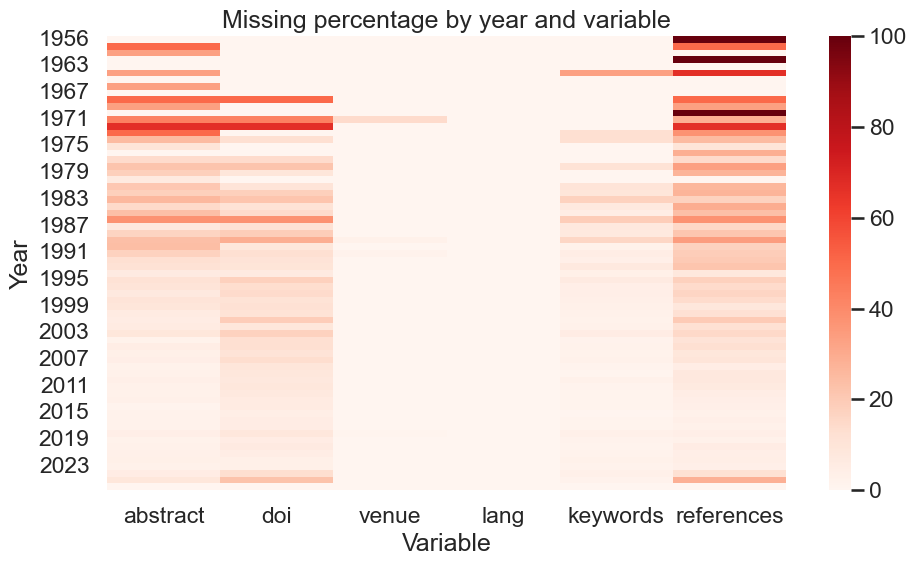

In [38]:
important_cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

heatmap_df = pd.DataFrame(index=sorted(df["year"].dropna().astype(int).unique()))

for col in important_cols:
    tmp = (
        df.dropna(subset=["year"])
          .assign(year=lambda x: x["year"].astype(int),
                  missing=lambda x: x[col].apply(is_empty))
          .groupby("year")["missing"]
          .mean()
          .mul(100)
    )
    heatmap_df[col] = tmp

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, cmap="Reds", annot=False)
plt.title("Missing percentage by year and variable")
plt.xlabel("Variable")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

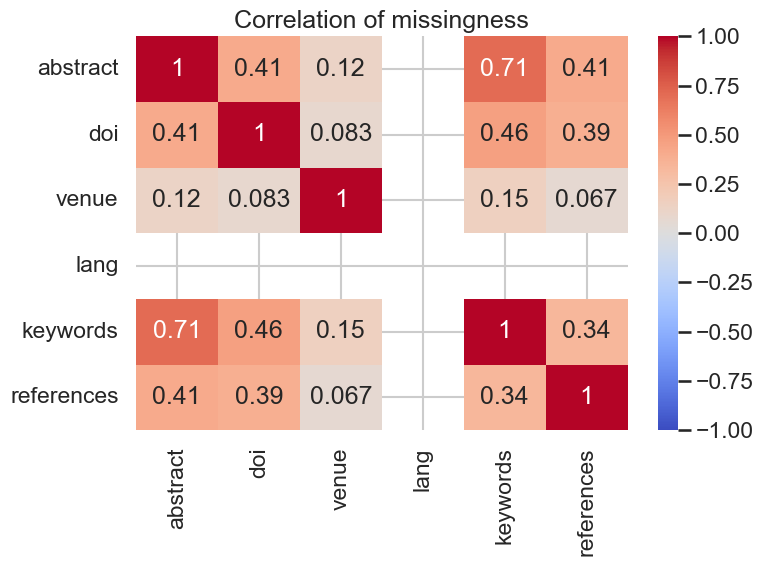

In [39]:
cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

missing_flags = pd.DataFrame({
    col: df[col].apply(is_empty).astype(int)
    for col in cols
})

corr = missing_flags.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of missingness")
plt.tight_layout()
plt.show()


matrice interessante per capire su quali features "usare" per fare filling di alcune missing

In [40]:
important_cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

def plot_missing_by_year(col):
    missing_by_year = (
        df.dropna(subset=["year"])
          .assign(
              year=lambda x: x["year"].astype(int),
              missing=lambda x: x[col].apply(is_empty)
          )
          .groupby("year")["missing"]
          .agg(["sum", "mean", "count"])
          .reset_index()
    )

    missing_by_year["mean"] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.lineplot(
        data=missing_by_year,
        x="year",
        y="sum",
        ax=axes[0],
        marker="o"
    )
    axes[0].set_title(f"Missing {col} by year")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Missing count")

    sns.lineplot(
        data=missing_by_year,
        x="year",
        y="mean",
        ax=axes[1],
        marker="o",
        color="#E45756"
    )
    axes[1].set_title(f"Missing {col} by year (%)")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Missing percentage")

    plt.tight_layout()
    plt.show()

widgets.interact(plot_missing_by_year, col=important_cols)

interactive(children=(Dropdown(description='col', options=('abstract', 'doi', 'venue', 'lang', 'keywords', 're…

<function __main__.plot_missing_by_year(col)>

plot per capire una prima similarità tra documenti

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import plotly.express as px

text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).fillna("")

vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X = vectorizer.fit_transform(text)

coords = PCA(n_components=2).fit_transform(X.toarray())

plot_df = df.copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="lang",
    hover_data=["title", "year", "venue"],
    title="Document map"
)
fig.show()

## Data Quality and Normalization

qui dobbiamo normalizzare testo, DOI, venue, doc_type e nomi autore, creare flag di qualità dati, evidenziare inconsistenze utili per il task finale

In [44]:
df_clean = df.copy()

In [45]:
import re
import math
import unicodedata
from collections import defaultdict

CURRENT_YEAR = 2026
MIN_REASONABLE_YEAR = 1950

ZERO_WIDTH_PATTERN = re.compile(r"[\u200b-\u200d\ufeff]")
MULTISPACE_PATTERN = re.compile(r"\s+")
PUNCT_TO_SPACE_PATTERN = re.compile(r"[^a-z0-9]+")
DOI_PREFIX_PATTERN = re.compile(r"^(https?://(dx\.)?doi\.org/|doi:)", re.IGNORECASE)

VENUE_REPLACEMENTS = {
    "intl": "international",
    "int'l": "international",
    "conf": "conference",
    "proc": "proceedings",
    "symp": "symposium",
    "sympos": "symposium",
    "worksh": "workshop",
    "trans": "transactions",
    "j": "journal",
}

DOC_TYPE_RULES = [
    ("conference", ("conference", "proceedings", "symposium", "workshop")),
    ("journal", ("journal", "transactions", "magazine")),
    ("book-chapter", ("chapter", "book chapter")),
    ("book", ("book",)),
    ("preprint", ("preprint", "posted content")),
    ("dissertation", ("dissertation", "thesis")),
    ("report", ("report", "technical report")),
]

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, float) and math.isnan(x):
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, np.ndarray):
        return x.size == 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    return False

def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    return []

def clean_string(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x).strip()

def normalize_text(x, lowercase=True):
    text = clean_string(x)
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text.lower() if lowercase else text

def strip_accents(x):
    text = normalize_text(x, lowercase=True)
    if not text:
        return ""
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))

def normalize_for_key(x):
    text = strip_accents(x)
    text = PUNCT_TO_SPACE_PATTERN.sub(" ", text)
    return MULTISPACE_PATTERN.sub(" ", text).strip()

def normalize_doi(x):
    doi = normalize_text(x, lowercase=True)
    if not doi:
        return ""
    doi = DOI_PREFIX_PATTERN.sub("", doi)
    return doi.strip().rstrip("/")

def normalize_author_name(x):
    name = normalize_text(x, lowercase=False)
    if not name:
        return ""

    if "," in name:
        left, right = [part.strip() for part in name.split(",", 1)]
        if left and right:
            name = f"{right} {left}"

    name = normalize_text(name, lowercase=True)
    name = re.sub(r"[.'`]", "", name)
    name = re.sub(r"[^a-z0-9\s\-]", " ", strip_accents(name))
    return MULTISPACE_PATTERN.sub(" ", name).strip()

def normalize_venue(x):
    venue = normalize_text(x, lowercase=True)
    if not venue:
        return ""

    venue = venue.replace("&", " and ")
    venue = re.sub(r"[./,;:()\-]+", " ", venue)

    tokens = []
    for token in venue.split():
        token = token.strip(".")
        tokens.append(VENUE_REPLACEMENTS.get(token, token))

    venue = " ".join(tokens)
    venue = strip_accents(venue)
    venue = re.sub(r"\bproc of the\b", "proceedings of", venue)
    venue = re.sub(r"\bproc\b", "proceedings", venue)
    return MULTISPACE_PATTERN.sub(" ", venue).strip()

def normalize_doc_type(x):
    text = normalize_text(x, lowercase=True)
    if not text:
        return ""
    for canonical, cues in DOC_TYPE_RULES:
        if any(cue in text for cue in cues):
            return canonical
    return text

def normalize_lang(x):
    lang = normalize_text(x, lowercase=True)
    return lang[:5] if lang else ""

def contains_non_ascii(text):
    return any(ord(ch) > 127 for ch in text)


In [46]:
df_clean["title_clean"] = df_clean["title"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["title_norm"] = df_clean["title"].apply(normalize_for_key)

df_clean["abstract_clean"] = df_clean["abstract"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["abstract_norm"] = df_clean["abstract"].apply(normalize_for_key)

df_clean["venue_clean"] = df_clean["venue"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["venue_norm"] = df_clean["venue"].apply(normalize_venue)

df_clean["doc_type_clean"] = df_clean["doc_type"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["doc_type_norm"] = df_clean["doc_type"].apply(normalize_doc_type)

df_clean["doi_norm"] = df_clean["doi"].apply(normalize_doi)
df_clean["lang_norm"] = df_clean["lang"].apply(normalize_lang)
df_clean["year_clean"] = pd.to_numeric(df_clean["year"], errors="coerce")

df_clean["keywords_norm"] = df_clean["keywords"].apply(
    lambda xs: list(dict.fromkeys([normalize_for_key(x) for x in ensure_list(xs) if normalize_for_key(x)]))
)
df_clean["n_keywords"] = df_clean["keywords_norm"].apply(len)
df_clean["n_references"] = df_clean["references"].apply(lambda x: len(ensure_list(x)))


In [48]:
cols_preview = [
    "title", "title_norm",
    "venue", "venue_norm",
    "doc_type", "doc_type_norm",
    "doi", "doi_norm",
    "lang", "lang_norm"
]
display(df_clean[cols_preview].head(10))


,title,title_norm,venue,venue_norm,doc_type,doc_type_norm,doi,doi_norm,lang,lang_norm
0,Top-Down Construction of 3-D Mechanical Object...,top down construction of 3 d mechanical object...,Computer,computer,Journal,journal,10.1109/mc.1984.1659026,10.1109/mc.1984.1659026,en,en
1,MH: A Multifarious User Agent.,mh a multifarious user agent,Computer Networks and ISDN Systems,computer networks and isdn systems,Journal,journal,10.1016/0169-7552(85)90077-7,10.1016/0169-7552(85)90077-7,en,en
2,Characterizing an Optimal Input in Perturbed C...,characterizing an optimal input in perturbed c...,Mathematical Programming,mathematical programming,Journal,journal,10.1007/bf02591721,10.1007/bf02591721,en,en
3,Theoretical Aspects of Sigma-programming,theoretical aspects of sigma programming,Lecture Notes in Computer Science Mathematical...,lecture notes in computer science mathematical...,Conference,conference,10.1007/3-540-16444-8_13,10.1007/3-540-16444-8_13,en,en
4,I 3 R: a New Approach to the Design of Documen...,i 3 r a new approach to the design of document...,Journal of the American Society for Informatio...,journal of the american society for informatio...,Journal,journal,10.1002/(sici)1097-4571(198711)38:6<389::aid-a...,10.1002/(sici)1097-4571(198711)38:6<389::aid-a...,en,en
5,The Use of Fuzzy Information Retrieval Techniq...,the use of fuzzy information retrieval techniq...,International Conference on Information Proces...,international conference on information proces...,Conference,conference,10.1007/3-540-18579-8_25,10.1007/3-540-18579-8_25,en,en
6,Solving Equations of Motion on a Virtual Tree ...,solving equations of motion on a virtual tree ...,SIAM Journal on Scientific and Statistical Com...,siam journal on scientific and statistical com...,Conference,conference,10.1137/0908013,10.1137/0908013,en,en
7,Simplified Voronoi Diagrams,simplified voronoi diagrams,Latest Advances in Robot Kinematics,latest advances in robot kinematics,Conference,conference,10.1007/bf02187909,10.1007/bf02187909,en,en
8,A Semantic Approach For Modular Synthesis Of V...,a semantic approach for modular synthesis of v...,INFORMATION PROCESSING LETTERS,information processing letters,Journal,journal,10.1016/0020-0190(88)90073-7,10.1016/0020-0190(88)90073-7,en,en
9,Measuring Parallelism in Computation-Intensive...,measuring parallelism in computation intensive...,IEEE Transactions on Computers,ieee transactions on computers,Journal,journal,10.1109/12.2259,10.1109/12.2259,en,en


In [49]:
def extract_author_features(authors):
    authors = ensure_list(authors)

    author_names_raw = []
    author_names_norm = []
    author_names_ascii = []
    author_ids_clean = []
    author_orgs_clean = []
    author_missing_id_count = 0
    author_missing_org_count = 0
    author_non_ascii_count = 0

    pairs = []

    for author in authors:
        if not isinstance(author, dict):
            continue

        raw_name = normalize_text(author.get("name"), lowercase=False)
        norm_name = normalize_author_name(author.get("name"))
        ascii_name = normalize_for_key(author.get("name"))
        author_id = normalize_text(author.get("id"), lowercase=False)
        author_org = normalize_text(author.get("org"), lowercase=False)

        if raw_name:
            author_names_raw.append(raw_name)
        if norm_name:
            author_names_norm.append(norm_name)
        if ascii_name:
            author_names_ascii.append(ascii_name)
        if raw_name and ascii_name:
            pairs.append((raw_name, ascii_name))

        if author_id:
            author_ids_clean.append(author_id)
        else:
            author_missing_id_count += 1

        if author_org:
            author_orgs_clean.append(author_org)
        else:
            author_missing_org_count += 1

        if raw_name and contains_non_ascii(raw_name):
            author_non_ascii_count += 1

    seen = set()
    unique_pairs = []
    for pair in pairs:
        if pair not in seen:
            seen.add(pair)
            unique_pairs.append(pair)

    raw_by_ascii = defaultdict(set)
    for raw_name, ascii_name in unique_pairs:
        raw_by_ascii[ascii_name].add(raw_name)

    flag_author_name_variants_in_paper = any(len(v) > 1 for v in raw_by_ascii.values())

    return pd.Series({
        "author_names_raw": [raw for raw, _ in unique_pairs],
        "author_names_norm": list(dict.fromkeys(author_names_norm)),
        "author_names_ascii": [ascii_name for _, ascii_name in unique_pairs],
        "author_ids_clean": list(dict.fromkeys(author_ids_clean)),
        "author_orgs_clean": list(dict.fromkeys(author_orgs_clean)),
        "n_authors": len(author_names_raw),
        "author_missing_id_count": author_missing_id_count,
        "author_missing_org_count": author_missing_org_count,
        "author_non_ascii_count": author_non_ascii_count,
        "flag_author_name_variants_in_paper": flag_author_name_variants_in_paper
    })

author_features = df_clean["authors"].apply(extract_author_features)
df_clean = pd.concat([df_clean, author_features], axis=1)


In [50]:
display(
    df_clean[
        [
            "authors",
            "author_names_raw",
            "author_names_norm",
            "author_names_ascii",
            "n_authors",
            "author_missing_id_count",
            "author_missing_org_count"
        ]
    ].head(5)
)


,authors,author_names_raw,author_names_norm,author_names_ascii,n_authors,author_missing_id_count,author_missing_org_count
0,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H...","[H YOSHIURA, K FUJIMURA, TL KUNII]","[h yoshiura, k fujimura, tl kunii]","[h yoshiura, k fujimura, tl kunii]",3,0,1
1,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {...","[MT ROSE, EA STEFFERUD, JN SWEET]","[mt rose, ea stefferud, jn sweet]","[mt rose, ea stefferud, jn sweet]",3,3,3
2,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S...",[S. Zlobec],[s zlobec],[s zlobec],1,0,0
3,"[{'id': '65570cb0145e064b7afc5d53', 'name': 'G...","[Goncharov S. S., Sviridenko D. I.]","[goncharov s s, sviridenko d i]","[goncharov s s, sviridenko d i]",2,0,2
4,"[{'id': '53f459c4dabfaee2a1d80cdf', 'name': 'W...","[WB CROFT, RH THOMPSON]","[wb croft, rh thompson]","[wb croft, rh thompson]",2,0,0


In [51]:
def venue_doc_type_conflict(venue_norm, doc_type_norm):
    if not venue_norm or not doc_type_norm:
        return False

    venue_looks_conference = any(token in venue_norm for token in ["conference", "proceedings", "symposium", "workshop"])
    venue_looks_journal = any(token in venue_norm for token in ["journal", "transactions", "magazine"])

    return (
        (venue_looks_conference and doc_type_norm == "journal") or
        (venue_looks_journal and doc_type_norm == "conference")
    )

df_clean["flag_missing_title"] = df_clean["title_clean"].eq("")
df_clean["flag_missing_abstract"] = df_clean["abstract_clean"].eq("")
df_clean["flag_missing_venue"] = df_clean["venue_clean"].eq("")
df_clean["flag_missing_doc_type"] = df_clean["doc_type_clean"].eq("")
df_clean["flag_missing_doi"] = df_clean["doi_norm"].eq("")
df_clean["flag_missing_keywords"] = df_clean["n_keywords"].eq(0)
df_clean["flag_missing_references"] = df_clean["n_references"].eq(0)
df_clean["flag_missing_authors"] = df_clean["n_authors"].eq(0)

df_clean["flag_author_id_missing_any"] = df_clean["author_missing_id_count"].gt(0)
df_clean["flag_author_org_missing_any"] = df_clean["author_missing_org_count"].gt(0)
df_clean["flag_author_non_ascii_present"] = df_clean["author_non_ascii_count"].gt(0)

df_clean["flag_year_missing"] = df_clean["year_clean"].isna()
df_clean["flag_year_suspicious"] = df_clean["year_clean"].apply(
    lambda x: False if pd.isna(x) else int(x) < MIN_REASONABLE_YEAR or int(x) > CURRENT_YEAR + 1
)
df_clean["flag_doc_type_unknown"] = df_clean["doc_type_norm"].eq("")
df_clean["flag_venue_doc_type_conflict"] = [
    venue_doc_type_conflict(v, d)
    for v, d in zip(df_clean["venue_norm"], df_clean["doc_type_norm"])
]

quality_cols = [
    "flag_missing_title",
    "flag_missing_abstract",
    "flag_missing_venue",
    "flag_missing_doc_type",
    "flag_missing_doi",
    "flag_missing_keywords",
    "flag_missing_references",
    "flag_missing_authors",
    "flag_author_id_missing_any",
    "flag_author_org_missing_any",
    "flag_year_missing",
    "flag_year_suspicious",
    "flag_venue_doc_type_conflict"
]

df_clean["quality_score"] = df_clean[quality_cols].sum(axis=1).astype(int)


In [52]:
quality_summary = pd.DataFrame({
    "count": df_clean[quality_cols].sum().astype(int),
    "pct": (df_clean[quality_cols].mean() * 100).round(2)
}).sort_values("count", ascending=False)

display(quality_summary)


,count,pct
flag_author_org_missing_any,2237,22.37
flag_author_id_missing_any,1894,18.94
flag_missing_doi,875,8.75
flag_missing_references,810,8.10
flag_missing_abstract,453,4.53
flag_missing_keywords,231,2.31
flag_venue_doc_type_conflict,224,2.24
flag_missing_venue,14,0.14
flag_missing_doc_type,10,0.10
flag_missing_title,0,0.00


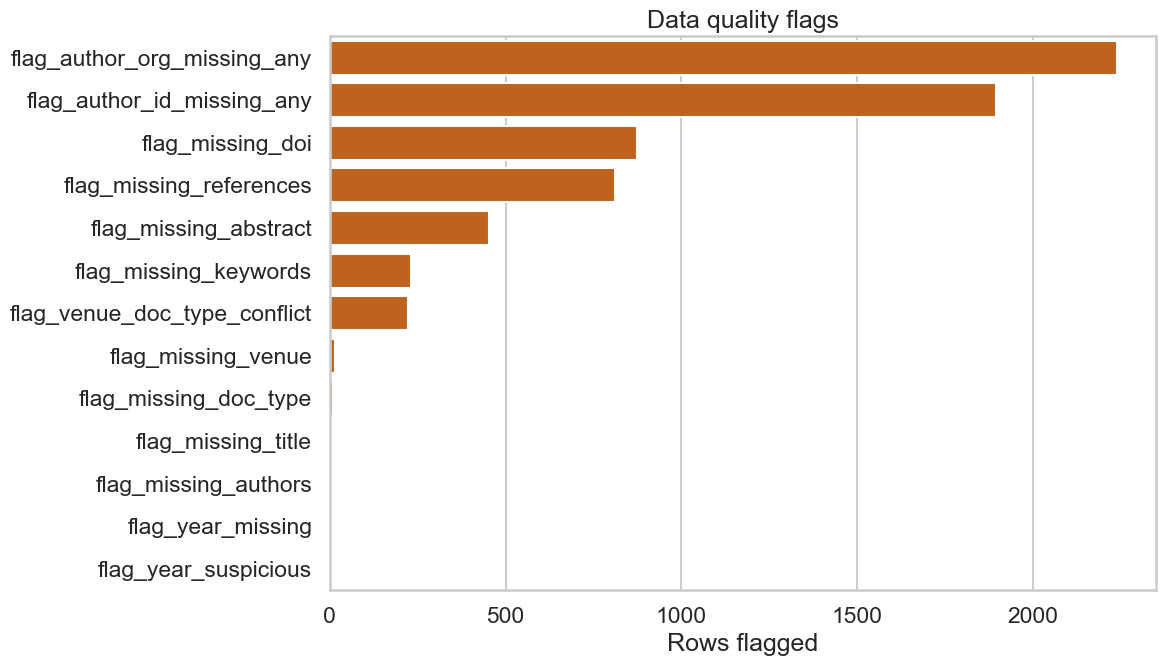

In [53]:
plot_df = quality_summary.reset_index().rename(columns={"index": "flag"})

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="count", y="flag", color="#D95F02")
plt.title("Data quality flags")
plt.xlabel("Rows flagged")
plt.ylabel("")
plt.tight_layout()
plt.show()


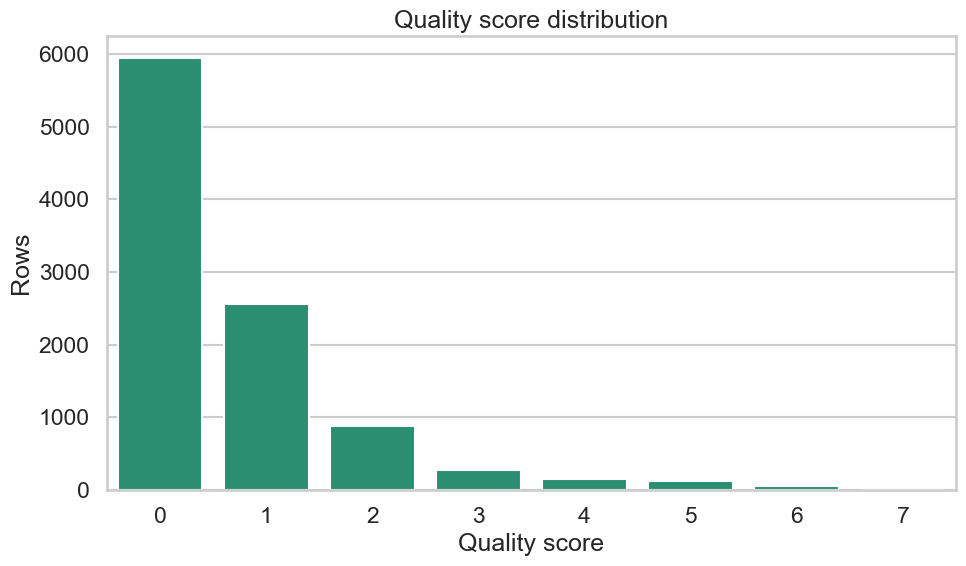

In [54]:
score_dist = (
    df_clean["quality_score"]
    .value_counts()
    .sort_index()
    .rename_axis("quality_score")
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=score_dist, x="quality_score", y="count", color="#1B9E77")
plt.title("Quality score distribution")
plt.xlabel("Quality score")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


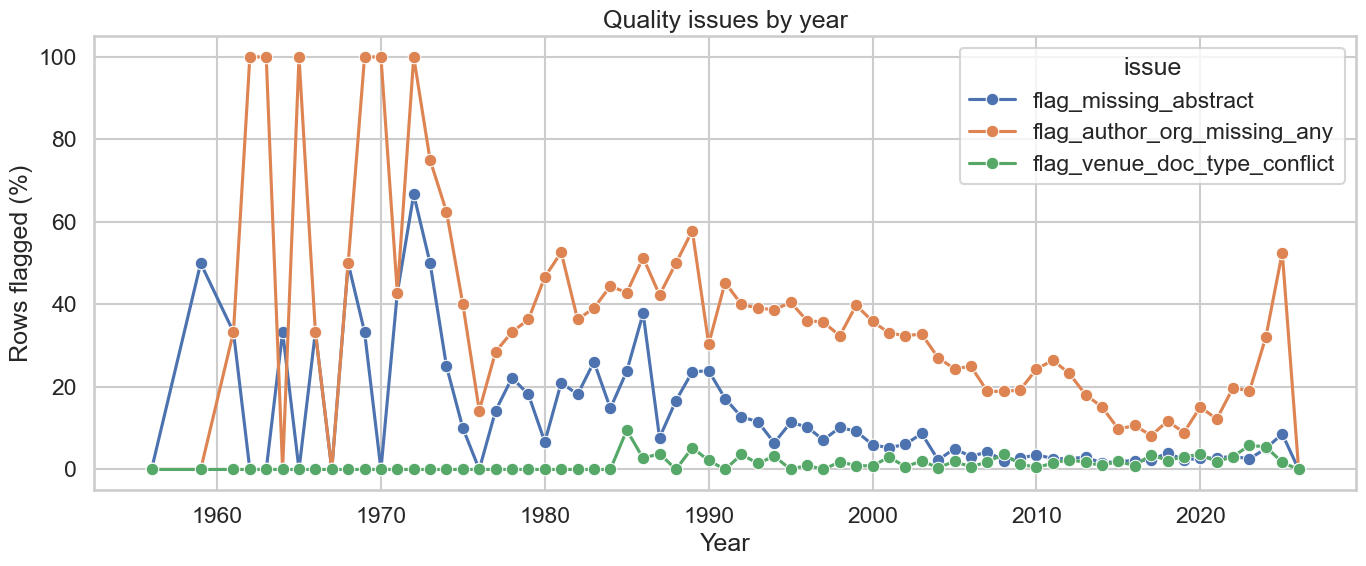

In [55]:
year_quality = (
    df_clean.dropna(subset=["year_clean"])
    .assign(year_clean=lambda x: x["year_clean"].astype(int))
    .groupby("year_clean")[[
        "flag_missing_abstract",
        "flag_author_org_missing_any",
        "flag_venue_doc_type_conflict"
    ]]
    .mean()
    .mul(100)
    .reset_index()
)

year_quality_long = year_quality.melt(id_vars="year_clean", var_name="issue", value_name="pct")

plt.figure(figsize=(14, 6))
sns.lineplot(data=year_quality_long, x="year_clean", y="pct", hue="issue", marker="o")
plt.title("Quality issues by year")
plt.xlabel("Year")
plt.ylabel("Rows flagged (%)")
plt.tight_layout()
plt.show()


In [56]:
author_alias_rows = []

for _, row in df_clean.iterrows():
    raw_names = row["author_names_raw"]
    ascii_names = row["author_names_ascii"]

    for raw_name, ascii_name in zip(raw_names, ascii_names):
        author_alias_rows.append({
            "author_ascii": ascii_name,
            "author_raw": raw_name
        })

author_alias_df = pd.DataFrame(author_alias_rows)

author_alias_summary = (
    author_alias_df.groupby("author_ascii")
    .agg(
        n_variants=("author_raw", "nunique"),
        examples=("author_raw", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
    )
    .reset_index()
    .sort_values(["n_variants", "author_ascii"], ascending=[False, True])
)

author_alias_summary = author_alias_summary[author_alias_summary["n_variants"] > 1]
display(author_alias_summary.head(20))


,author_ascii,n_variants,examples
11027,j yang,3,J YANG | J Yang | J. Yang
54,a choudhary,2,A CHOUDHARY | A Choudhary
754,ak majumdar,2,AK Majumdar | Ak Majumdar
1215,ali zemouche,2,Ali Zemouche | ali zemouche
1531,anderson santana de oliveira,2,Anderson Santana De Oliveira | Anderson Santan...
1689,andrei paun,2,Andrei Paun | Andrei Păun
2534,b chan,2,B Chan | B. Chan
2674,balazs csanad csaji,2,Balazs Csanad Csaji | Balázs Csanád Csáji
3724,carmen garcia mateo,2,Carmen Garcia-Mateo | Carmen García-Mateo
5062,d sylvester,2,D SYLVESTER | D Sylvester


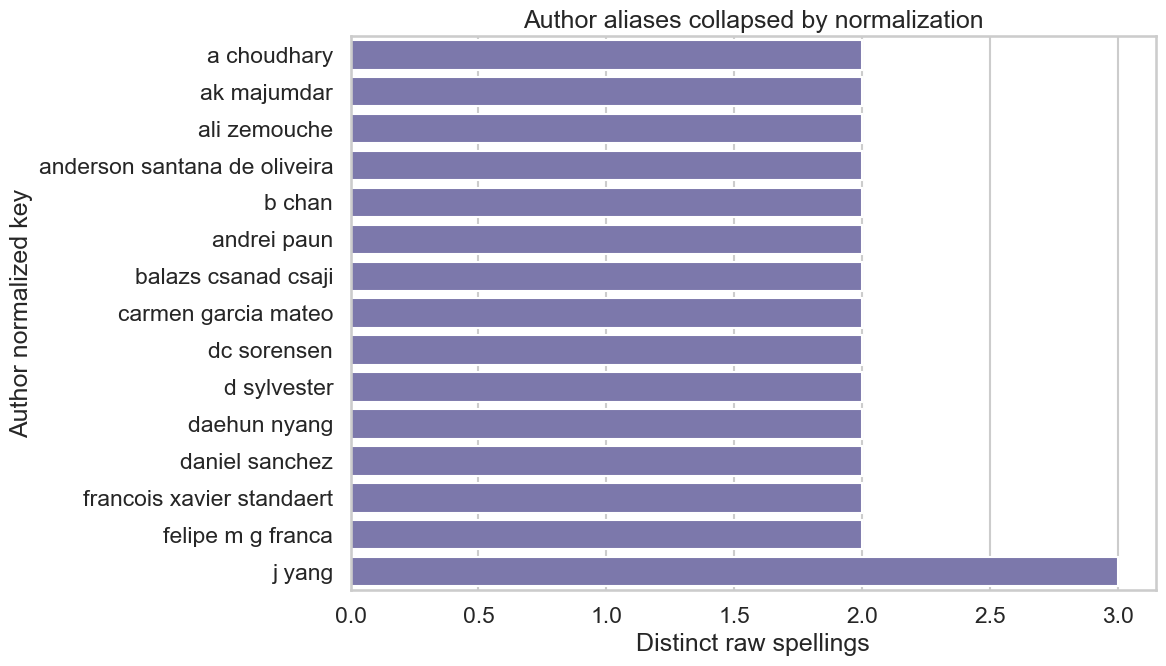

In [57]:
top_author_alias = author_alias_summary.head(15).sort_values("n_variants", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_author_alias, x="n_variants", y="author_ascii", color="#7570B3")
plt.title("Author aliases collapsed by normalization")
plt.xlabel("Distinct raw spellings")
plt.ylabel("Author normalized key")
plt.tight_layout()
plt.show()


In [58]:
venue_alias_df = (
    df_clean.loc[df_clean["venue_norm"] != "", ["venue_clean", "venue_norm"]]
    .drop_duplicates()
)

venue_alias_summary = (
    venue_alias_df.groupby("venue_norm")
    .agg(
        n_variants=("venue_clean", "nunique"),
        examples=("venue_clean", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
    )
    .reset_index()
    .sort_values(["n_variants", "venue_norm"], ascending=[False, True])
)

venue_alias_summary = venue_alias_summary[venue_alias_summary["n_variants"] > 1]
display(venue_alias_summary.head(20))


,venue_norm,n_variants,examples
1770,computers and electrical engineering,4,COMPUTERS & ELECTRICAL ENGINEERING | Computers...
2821,ieee transactions on circuits and systems ii e...,4,IEEE TRANSACTIONS ON CIRCUITS AND SYSTEMS II-E...
4272,neural computing and applications,4,NEURAL COMPUTING & APPLICATIONS | Neural Compu...
1093,acm transactions on computational logic,3,ACM TRANSACTIONS ON COMPUTATIONAL LOGIC | ACM ...
1098,acm transactions on intelligent systems and te...,3,ACM TRANSACTIONS ON INTELLIGENT SYSTEMS AND TE...
1495,briefings in bioinformatics,3,BRIEFINGS IN BIOINFORMATICS | Briefings in Bio...
1702,computational statistics and data analysis,3,COMPUTATIONAL STATISTICS & DATA ANALYSIS | Com...
1766,computers and chemistry,3,Computers & Chemistry | Computers & chemistry ...
1776,computers and industrial engineering,3,COMPUTERS & INDUSTRIAL ENGINEERING | Computers...
1777,computers and mathematics with applications,3,COMPUTERS & MATHEMATICS WITH APPLICATIONS | Co...


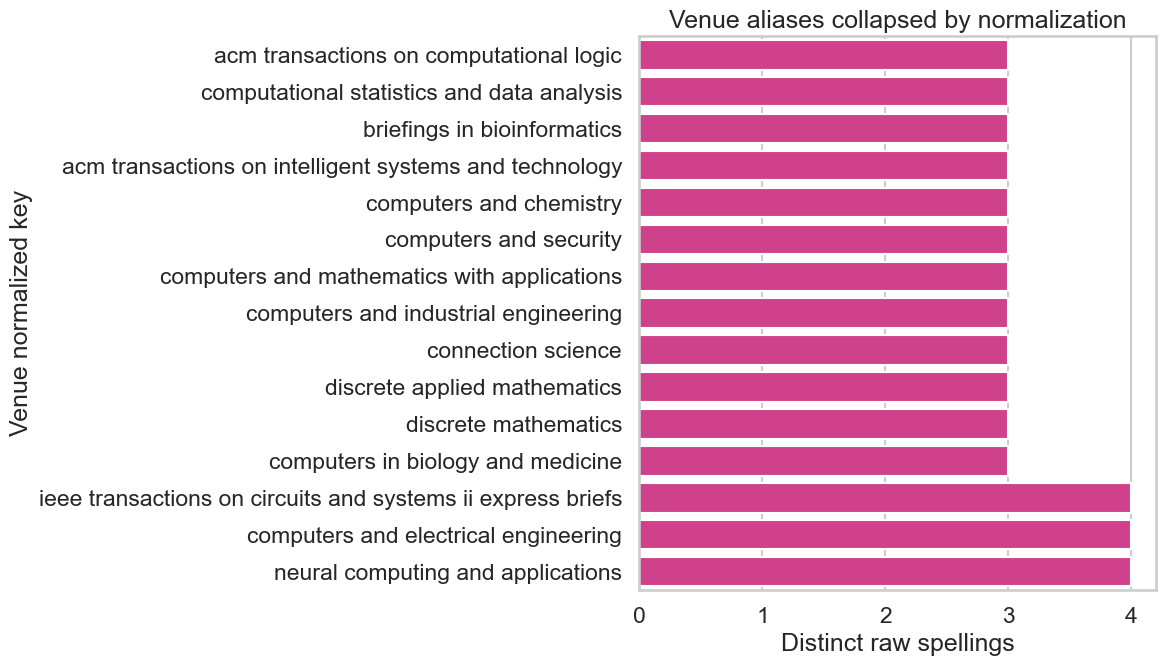

In [59]:
top_venue_alias = venue_alias_summary.head(15).sort_values("n_variants", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_venue_alias, x="n_variants", y="venue_norm", color="#E7298A")
plt.title("Venue aliases collapsed by normalization")
plt.xlabel("Distinct raw spellings")
plt.ylabel("Venue normalized key")
plt.tight_layout()
plt.show()


In [60]:
conflict_examples = df_clean.loc[
    df_clean["flag_venue_doc_type_conflict"],
    ["id", "title", "year_clean", "venue_clean", "venue_norm", "doc_type_clean", "doc_type_norm"]
].copy()

print(f"Numero di conflitti venue/doc_type: {len(conflict_examples):,}")
display(conflict_examples.head(20))


Numero di conflitti venue/doc_type: 224


,id,title,year_clean,venue_clean,venue_norm,doc_type_clean,doc_type_norm
6,5390878720f70186a0d345fe,Solving Equations of Motion on a Virtual Tree ...,1987,SIAM Journal on Scientific and Statistical Com...,siam journal on scientific and statistical com...,Conference,conference
14,5390879220f70186a0d3c37f,Efficient Parallel Algorithms for Path Problem...,1989,SPAA 89 PROCEEDINGS OF THE 1989 ACM SYMPOSIUM ...,spaa 89 proceedings of the 1989 acm symposium ...,Journal,journal
21,5390879920f70186a0d40bb1,A Characterization of Eventual Byzantine Agree...,2001,SIAM Journal on Computing,siam journal on computing,Conference,conference
42,539087b320f70186a0d500c4,A Multilevel Testability Assistant for VLSI De...,1992,European Design Automation Conference,european design automation conference,Journal,journal
119,5390882d20f70186a0d8db18,Parallel Scheduling Problems in Next Generatio...,2002,Proceedings of the fourteenth annual ACM sympo...,proceedings of the fourteenth annual acm sympo...,Journal,journal
203,53908b6c20f70186a0dbf3dc,An Integrity Constraint for Database Systems C...,2001,International Journal of Intelligent Systems,international journal of intelligent systems,Conference,conference
216,53908bcc20f70186a0dc5764,Taxonomies for Automated Question Triage in Di...,2003,ACM/IEEE Joint Conference on Digital Libraries,acm ieee joint conference on digital libraries,Journal,journal
242,5390958920f70186a0dee79d,RE in Flatness Measurement and Control Systems...,2004,Journal of Lightwave Technology,journal of lightwave technology,Conference,conference
332,539099a220f70186a0e16e64,Greedy Algorithms for Client Assignment in Lar...,2008,SIMULATION-TRANSACTIONS OF THE SOCIETY FOR MOD...,simulation transactions of the society for mod...,Conference,conference
454,5390a01420f70186a0e4830c,Searching for Expertise: Experiments with the ...,2008,The Computer Journal,the computer journal,Conference,conference


In [61]:
author_problem_examples = df_clean.loc[
    df_clean["flag_author_id_missing_any"] | df_clean["flag_author_org_missing_any"] | df_clean["flag_author_name_variants_in_paper"],
    [
        "id",
        "title",
        "year_clean",
        "author_names_raw",
        "author_names_norm",
        "author_ids_clean",
        "author_orgs_clean",
        "author_missing_id_count",
        "author_missing_org_count",
        "flag_author_name_variants_in_paper"
    ]
].copy()

display(author_problem_examples.head(20))


,id,title,year_clean,author_names_raw,author_names_norm,author_ids_clean,author_orgs_clean,author_missing_id_count,author_missing_org_count,flag_author_name_variants_in_paper
0,5390877920f70186a0d2ce7f,Top-Down Construction of 3-D Mechanical Object...,1984,"[H YOSHIURA, K FUJIMURA, TL KUNII]","[h yoshiura, k fujimura, tl kunii]","[62aad3b2d9f2040d085dc9f9, 5608ec4a45cedb3396d...","[Hitachi Research Laboratory, Hitachi Ltd., Un...",0,1,False
1,5390877920f70186a0d2d85b,MH: A Multifarious User Agent.,1985,"[MT ROSE, EA STEFFERUD, JN SWEET]","[mt rose, ea stefferud, jn sweet]",[],[],3,3,False
3,5390877f20f70186a0d2fca6,Theoretical Aspects of Sigma-programming,1986,"[Goncharov S. S., Sviridenko D. I.]","[goncharov s s, sviridenko d i]","[65570cb0145e064b7afc5d53, 64ce165f75f2d368222...",[],0,2,False
6,5390878720f70186a0d345fe,Solving Equations of Motion on a Virtual Tree ...,1987,"[WW ARMSTRONG, TA MARSLAND, M OLAFSSON, J SCHA...","[ww armstrong, ta marsland, m olafsson, j scha...","[53f437cfdabfaee1c0aaa494, 53f384a5dabfae4b34a...","[UNIV ALBERTA,DEPT COMP SCI,EDMONTON T6G 2H1,A...",0,3,False
7,5390878720f70186a0d356b5,Simplified Voronoi Diagrams,2012,"[Rubén Vaca, Joan Aranda, Federico Thomas]","[ruben vaca, joan aranda, federico thomas]","[65254fbc55b3f8ac4673059d, 5448a7fcdabfae87b7e...",[Department of Automatic Control and Computing...,1,0,False
8,5390878720f70186a0d361a7,A Semantic Approach For Modular Synthesis Of V...,1988,"[M Balakrishnan, S Sutarwala, Ak Majumdar, Dk ...","[m balakrishnan, s sutarwala, ak majumdar, dk ...","[562bce6145ce1e596718f72d, 53f63575dabfaeee839...","[UNIV GUELPH,DEPT COMP & INFORMAT SCI,GUELPH N...",1,0,False
10,5390878a20f70186a0d37b46,The POSTGRES Rule Manager.,1988,"[M STONEBRAKER, EN HANSON, S POTAMIANOS]","[m stonebraker, en hanson, s potamianos]","[53f43600dabfaedce552bb22, 53f3692bdabfae4b349...","[UNIV CALIF BERKELEY,DEPT ELECT ENGN & COMP SC...",1,0,False
12,5390878e20f70186a0d3a189,The Preconditioned Conjugate Gradient Method o...,1988,"[G. Abe, K. Hane]","[g abe, k hane]",[53f37cb6dabfae4b349e819d],"[Department of Electrical Engineering, Keio Un...",1,0,False
13,5390878e20f70186a0d3af5c,Design and Performance Evaluation of an Optica...,1989,"[S CASALE, V CATANIA, A FARO, N PARCHENKOV, L ...","[s casale, v catania, a faro, n parchenkov, l ...","[562f5d5f45cedb339963822b, 53f7a35fdabfae92b40...","[UNIV CATANIA,IST INFORMAT & TELECOMMUN,VIALE ...",2,4,False
15,5390879220f70186a0d3cb08,Use and Productivity in Personal Computing.,1989,[BT PENTLAND],[bt pentland],[53f431f0dabfaee0d9b36c42],[],0,1,False


In [62]:
cols_for_next_steps = [
    "id",
    "title",
    "title_norm",
    "abstract",
    "abstract_norm",
    "keywords",
    "keywords_norm",
    "year",
    "year_clean",
    "authors",
    "author_names_raw",
    "author_names_norm",
    "author_names_ascii",
    "author_ids_clean",
    "author_orgs_clean",
    "n_authors",
    "references",
    "n_references",
    "lang",
    "lang_norm",
    "doi",
    "doi_norm",
    "venue",
    "venue_clean",
    "venue_norm",
    "doc_type",
    "doc_type_clean",
    "doc_type_norm",
    "n_keywords",
    "quality_score"
] + quality_cols

df_model_base = df_clean[cols_for_next_steps].copy()
print(df_model_base.shape)
display(df_model_base.head(3))

(10000, 43)


,id,title,title_norm,abstract,abstract_norm,keywords,keywords_norm,year,year_clean,authors,...,flag_missing_doc_type,flag_missing_doi,flag_missing_keywords,flag_missing_references,flag_missing_authors,flag_author_id_missing_any,flag_author_org_missing_any,flag_year_missing,flag_year_suspicious,flag_venue_doc_type_conflict
0,5390877920f70186a0d2ce7f,Top-Down Construction of 3-D Mechanical Object...,top down construction of 3 d mechanical object...,,,"[First Page, 3-D Mechanical Object Shapes, Eng...","[first page, 3 d mechanical object shapes, eng...",1984,1984,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H...",...,False,False,False,False,False,False,True,False,False,False
1,5390877920f70186a0d2d85b,MH: A Multifarious User Agent.,mh a multifarious user agent,The UCI version of the Rand Message Handling S...,the uci version of the rand message handling s...,"[Computer network mail, Distributed mail syste...","[computer network mail, distributed mail syste...",1985,1985,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {...",...,False,False,False,False,False,True,True,False,False,False
2,5390877920f70186a0d2e433,Characterizing an Optimal Input in Perturbed C...,characterizing an optimal input in perturbed c...,When every feasible stable perturbation of dat...,when every feasible stable perturbation of dat...,"[Optimal input, region of stability, input con...","[optimal input, region of stability, input con...",1983,1983,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S...",...,False,False,False,False,False,False,False,False,False,False
